# Static 📺
### "Buy the calm stocks" — the low-vol puzzle, inverted on large caps

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Idio-vol puzzle on large caps?: Busted](https://img.shields.io/badge/Idio--vol_puzzle_on_large_caps%3F-Busted-8b949e?style=flat-square)

One of finance's famous puzzles: stocks with high firm-specific volatility earn *lower* returns, not higher — risk seemingly punished. On large-cap stocks the trade ran backwards and lost ~12%/yr, because the volatile growth names were exactly the winners. The near-twin of the lottery (MAX) effect — same axis, same inversion.

> 📓 **Plain-language layer.** The t-stat and the MAX twin are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (static/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from static import data, strategy as st
daily, mkt = data.fetch_panel()                # cache-first
sig = st.idiovol_signal(daily, mkt)
textbook = st.cross_section_hedge(daily, sig, long_high=False)   # long low idio-vol


## The answer first 🎯

| The puzzle | On large caps (2000–2026) |
|---|---|
| "High-idio-vol stocks earn less" | They earned **more**: textbook trade **−12.1%/yr**. |
| "Buy calm, short volatile" | That *cost* you (Sharpe −0.60, t −3.1). |
| "A robust puzzle" | Steady inversion (−0.65 in both halves). |

## 1 · The claim

Ang, Hodrick, Xing & Zhang (2006): a stock's idiosyncratic volatility — the part of its return not explained by the market — predicts *low* future returns. Long low-idio-vol, short high-idio-vol.

## 2 · So what?

A puzzle worth a fortune if tradable: get higher returns *and* lower risk. But idio-vol is a high-risk proxy, and whether 'low risk wins' depends on the universe and the regime — exactly what we test.

## 3 · How would we even know?

Estimate each stock's idio-vol from a rolling market regression, rank, run the textbook long-low/short-high trade, and check the sign, significance and persistence.

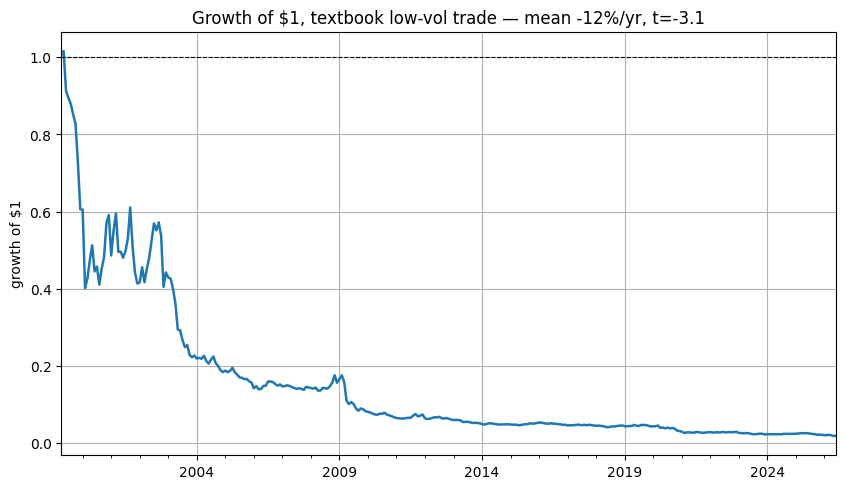

In [2]:
s=st.stats(textbook); eq=(1+textbook).cumprod()
ax=eq.plot(title=f"Growth of $1, textbook low-vol trade — mean {s['mean_ann']:+.0%}/yr, t={s['tstat']:.1f}",lw=1.8)
ax.axhline(1.0,color='k',lw=.8,ls='--'); ax.set_ylabel('growth of $1'); plt.show()

## 4 · The teardown

A line heading down — buying calm and shorting volatile lost money, consistently. The high-idio-vol survivors were the market's leaders.

In [3]:
for lab,sl in [('2000-2012',textbook.loc[:'2012']),('2013-on',textbook.loc['2013':])]:
    print(f'{lab}: Sharpe {st.stats(sl)["sharpe"]:+.2f}, mean {st.stats(sl)["mean_ann"]:+.2%}/yr')

2000-2012: Sharpe -0.65, mean -16.55%/yr
2013-on: Sharpe -0.65, mean -7.56%/yr


**Read it plainly.** Same story as [Jackpot (MAX)](../../53-jackpot/) — idio-vol and MAX are two names for the high-risk axis, and on large caps high risk *won*. The puzzle is a small-cap phenomenon.

## 5 · The verdict

**Signal: None** — inverted (t −3.1). **Tradability: Mirage** — negative gross, steady. **Idio-vol puzzle on large caps?: Busted.**

## 6 · Could you actually trade it?

Not on liquid stocks. The low-vol premium needs the small, illiquid names and the delisted blow-ups that survivorship removes — the untradable end.

## 7 · Going further 🚪

Compare directly with its twin [Study 53 Jackpot](../../53-jackpot/) (MAX) and [Study 43 Free-Lunch](../../43-free-lunch/) (betting against beta) — three faces of the same large-cap-high-risk-won regime.